# Savitzky-Golay 

## $ y_{sg}[n] = \sum_{k = -m}^{m} C_k \times y_{n+k} $


### $y_{sg}[n] = $ filtered signals
### $C_k =$ Savitzky-Golay coeffiecents (Using Scipy)
### $m = \frac{window\_size}{2}$

In [1]:
import numpy as np
from scipy.signal import savgol_filter
import librosa
import pandas as pd

In [7]:
def load_audio(audio_path, sr):

    audio, sr = librosa.load(audio_path, sr = sr, mono=True)

    return audio, sr

In [8]:
def apply_savgol(audio, window_length=11, polyorder=3):

    # The window_length should be odd: 

    if (window_length%2==0):

        window_length += 1

    # The window_length should be <= Polyorder: 
    
    if (polyorder>=window_length):
        polyorder = window_length - 1

    audio_sg = savgol_filter(audio, window_length=window_length, polyorder=polyorder)

    return audio_sg

In [10]:
sr = 16000
audio_path = 'test_healthy_voice.wav'

audio, sr = load_audio(audio_path, sr)

In [17]:
sg=apply_savgol(audio, window_length=11, polyorder=3)

In [18]:
import matplotlib.pyplot as plt

time = np.arange(len(audio)) / sr

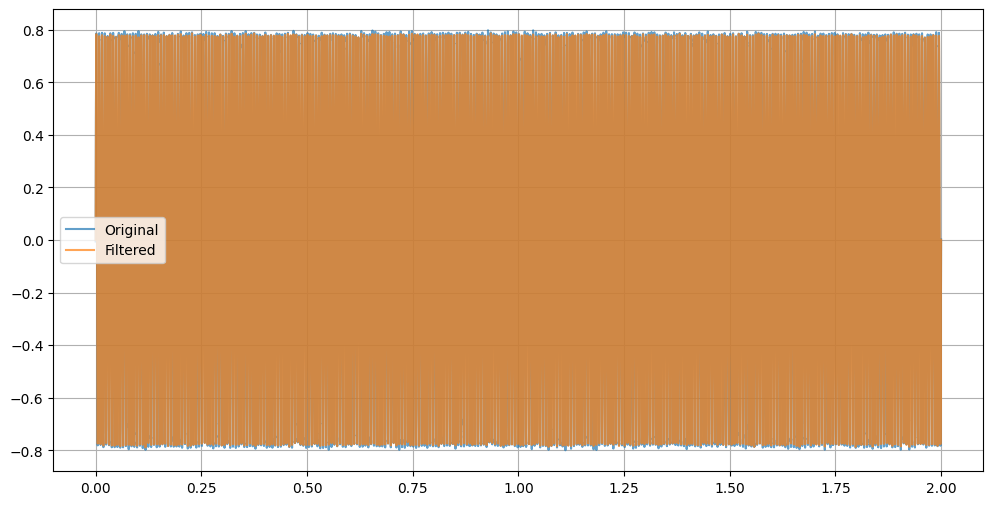

In [20]:
plt.figure(figsize=(12,6))
plt.plot(time, audio, label = 'Original', alpha = 0.7)
plt.plot(time, sg, label = 'Filtered', alpha = 0.7)

plt.legend()
plt.grid(True)
plt.show()

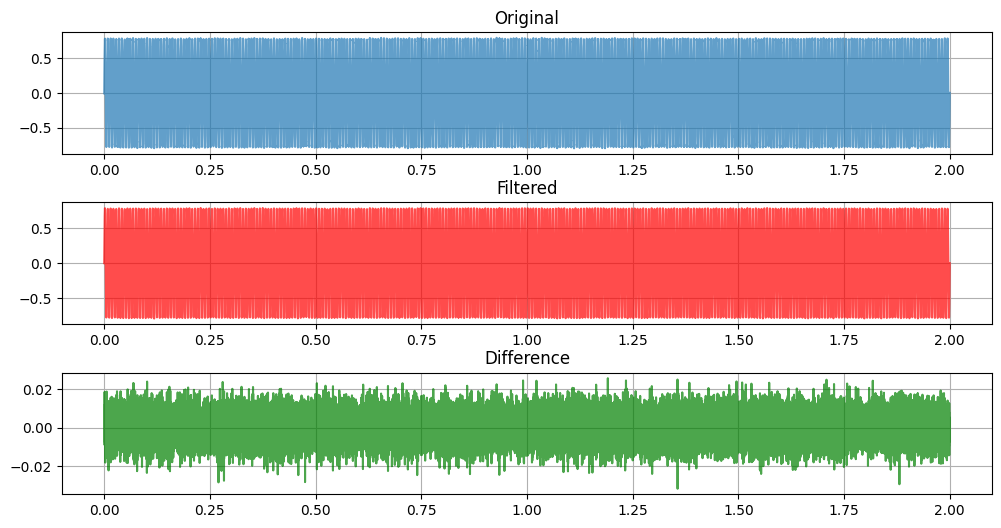

In [34]:
difference = audio - sg
plt.figure(figsize=(12,6))

plt.subplot(311)
plt.plot(time, audio, alpha = 0.7)
plt.title('Original')
plt.grid(True)


plt.subplot(312)
plt.plot(time, sg, alpha = 0.7, color = 'red')
plt.title('Filtered')
plt.grid(True)

plt.subplot(313)
plt.plot(time, difference, alpha= 0.7, color = 'green')
plt.title('Difference')
plt.grid(True)


plt.subplots_adjust(hspace=0.4)
plt.show()